# Language Classification Pipeline
This notebook builds a language classifier using **TF-IDF / CountVectorizer** with ML models.

**Key feature:** We augment training data with short conversational phrases so the model
handles inputs like `'hi'`, `'hola'`, `'bonjour'`, `'thanks'` correctly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    precision_recall_fscore_support, confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')

## 1. Load Dataset
We use the `papluca/language-identification` dataset (pre-split into train/validation/test).

In [2]:
dataset = load_dataset("papluca/language-identification")
df_train = dataset["train"].to_pandas()
df_val = dataset["validation"].to_pandas()
df_test = dataset["test"].to_pandas()

print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")
df_train.head()

README.md:   0%|          | 0.00/4.99k [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/12.0M [00:00<?, ?B/s]

valid.csv:   0%|          | 0.00/1.71M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/1.69M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/70000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Train: 70000, Val: 10000, Test: 10000


,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .


## 2. Exploratory Data Analysis

Missing values in train:
 labels    0
text      0
dtype: int64

Number of languages: 20
Languages: ['ar', 'bg', 'de', 'el', 'en', 'es', 'fr', 'hi', 'it', 'ja', 'nl', 'pl', 'pt', 'ru', 'sw', 'th', 'tr', 'ur', 'vi', 'zh']


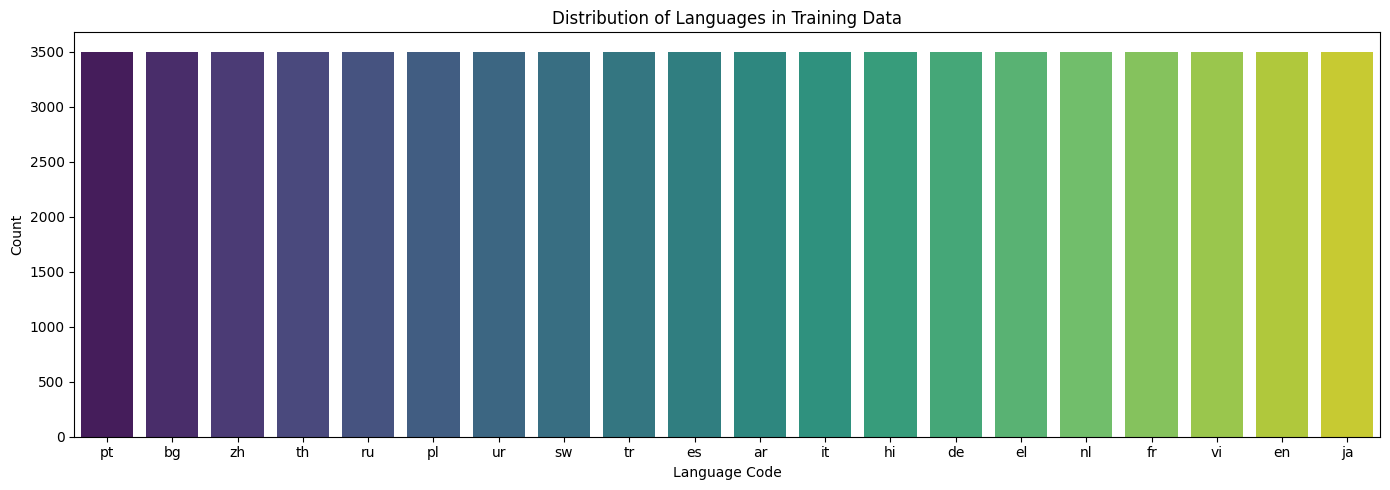

In [3]:
print("Missing values in train:\n", df_train.isnull().sum())
print(f"\nNumber of languages: {df_train['labels'].nunique()}")
print(f"Languages: {sorted(df_train['labels'].unique())}")

plt.figure(figsize=(14, 5))
order = df_train["labels"].value_counts().index
sns.countplot(data=df_train, x="labels", hue="labels", order=order, palette="viridis", legend=False)
plt.title("Distribution of Languages in Training Data")
plt.xlabel("Language Code")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

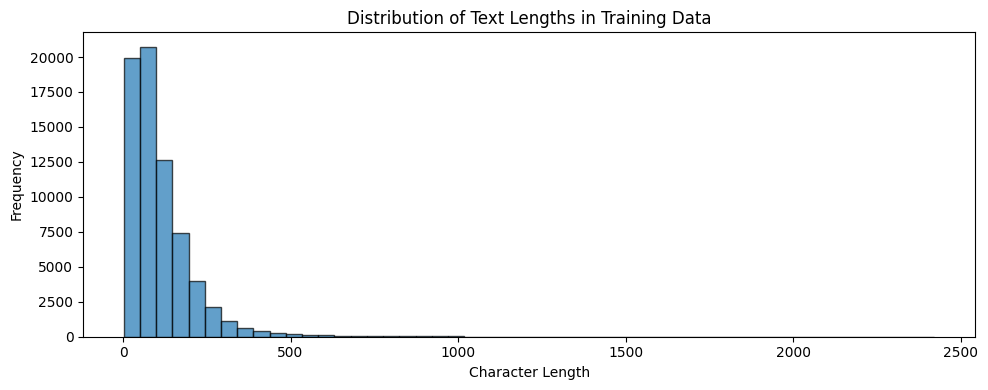

Min length: 2, Mean: 110.9, Max: 2422


In [4]:
# Text length distribution
df_train["text_len"] = df_train["text"].str.len()
plt.figure(figsize=(10, 4))
plt.hist(df_train["text_len"], bins=50, edgecolor="black", alpha=0.7)
plt.title("Distribution of Text Lengths in Training Data")
plt.xlabel("Character Length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
print(f"Min length: {df_train['text_len'].min()}, Mean: {df_train['text_len'].mean():.1f}, Max: {df_train['text_len'].max()}")
df_train.drop(columns=["text_len"], inplace=True)

## 3. Preprocessing
Drop Swahili (`sw`) — not needed for our use case.

In [5]:
# df_train = df_train[df_train["labels"] != "sw"].reset_index(drop=True)
# df_val = df_val[df_val["labels"] != "sw"].reset_index(drop=True)
# df_test = df_test[df_test["labels"] != "sw"].reset_index(drop=True)
# print(f"After dropping sw -> Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

## 4. Short-Text Augmentation
The original dataset is mostly long sentences. Short inputs like `'hi'`, `'ok'`, `'hola'`
are heavily misclassified because the model never saw them during training.

We add a curated set of short conversational phrases per language to fix this.

In [6]:
short_text_augmentation = {
    "en": [
        "hi", "hello", "hey", "yo", "sup", "ok", "okay", "yes", "no", "yeah",
        "nah", "thanks", "thank you", "please", "sorry", "bye", "goodbye",
        "good morning", "good night", "how are you", "i am fine",
        "what is your name", "nice to meet you", "see you later",
        "i am happy", "i am sad", "help me", "i need help",
        "good", "bad", "great", "cool", "sure", "why", "what", "when",
        "where", "who", "how", "fine", "welcome", "love", "hate",
        "i am mohammed", "i am tired", "i feel good", "i feel bad",
        "tell me more", "i dont know", "me too", "same here",
        "no problem", "of course", "absolutely", "definitely", "maybe",
        "not sure", "i think so", "i agree", "i disagree",
        "happy", "sad", "angry", "scared", "anxious", "stressed",
        "depressed", "lonely", "hopeful", "grateful", "confused",
    ],
    "ar": [
        "مرحبا", "اهلا", "سلام", "شكرا", "نعم", "لا", "اسف", "وداعا",
        "صباح الخير", "مساء الخير", "تصبح على خير", "كيف حالك",
        "انا بخير", "ما اسمك", "تشرفنا", "الى اللقاء",
        "عامل ايه", "ازيك", "تمام", "حبيبي", "يلا", "خلاص",
        "ماشي", "طيب", "حاضر", "ان شاء الله", "الحمد لله",
        "احتاج مساعدة", "ساعدني", "انا حزين", "انا سعيد",
        "انا تعبان", "انا مبسوط", "مش كويس", "كويس",
    ],
    "fr": [
        "salut", "bonjour", "bonsoir", "merci", "oui", "non", "pardon",
        "au revoir", "bonne nuit", "comment allez-vous", "je suis bien",
        "je suis triste", "je suis content", "enchante", "a bientot",
        "s il vous plait", "de rien", "excusez-moi", "bienvenue",
        "comment ca va", "ca va", "bien", "mal", "super", "genial",
    ],
    "es": [
        "hola", "buenos dias", "buenas noches", "gracias", "si", "no",
        "perdon", "adios", "por favor", "de nada", "lo siento",
        "como estas", "estoy bien", "mucho gusto", "hasta luego",
        "que tal", "vale", "genial", "bien", "mal", "claro",
        "bueno", "amigo", "te quiero", "necesito ayuda",
    ],
    "de": [
        "hallo", "guten morgen", "guten abend", "gute nacht", "danke",
        "ja", "nein", "bitte", "entschuldigung", "tschuss", "auf wiedersehen",
        "wie geht es ihnen", "mir geht es gut", "freut mich",
        "gut", "schlecht", "super", "toll", "genau", "stimmt",
    ],
    "it": [
        "ciao", "buongiorno", "buonasera", "buonanotte", "grazie",
        "si", "no", "scusa", "per favore", "prego", "arrivederci",
        "come stai", "sto bene", "piacere", "a presto",
        "bene", "male", "perfetto", "bellissimo", "bravo",
    ],
    "pt": [
        "ola", "oi", "bom dia", "boa noite", "obrigado", "obrigada",
        "sim", "nao", "desculpa", "por favor", "tchau", "adeus",
        "como vai", "estou bem", "prazer", "ate logo",
        "bem", "mal", "legal", "tudo bem", "valeu",
    ],
    "ru": [
        "привет", "здравствуйте", "доброе утро", "спокойной ночи",
        "спасибо", "да", "нет", "извините", "пожалуйста",
        "до свидания", "пока", "как дела", "хорошо", "плохо",
        "отлично", "ладно", "конечно", "помогите",
    ],
    "zh": [
        "你好", "早上好", "晚安", "谢谢", "是", "不是", "对不起",
        "再见", "请", "不客气", "你好吗", "我很好", "很高兴认识你",
        "好", "不好", "太好了", "没问题", "帮帮我",
    ],
    "ja": [
        "こんにちは", "おはよう", "おやすみ", "ありがとう", "はい", "いいえ",
        "すみません", "さようなら", "お願いします", "どういたしまして",
        "元気ですか", "元気です", "よろしく", "大丈夫",
    ],
    "ko": [
        "안녕하세요", "안녕", "감사합니다", "네", "아니요", "미안합니다",
        "안녕히 가세요", "잘 자요", "괜찮아요", "좋아요", "싫어요",
    ],
    "tr": [
        "merhaba", "gunaydin", "iyi geceler", "tesekkurler", "evet",
        "hayir", "ozur dilerim", "hosca kal", "lutfen",
        "nasilsin", "iyiyim", "memnun oldum", "tamam",
    ],
    "nl": [
        "hallo", "goedemorgen", "goedenavond", "welterusten", "dank je",
        "ja", "nee", "sorry", "alsjeblieft", "tot ziens",
        "hoe gaat het", "goed", "slecht", "prima",
    ],
    "pl": [
        "czesc", "dzien dobry", "dobranoc", "dziekuje", "tak", "nie",
        "przepraszam", "do widzenia", "prosze", "jak sie masz",
        "dobrze", "zle", "super", "okej",
    ],
    "vi": [
        "xin chao", "chao buoi sang", "chuc ngu ngon", "cam on",
        "vang", "khong", "xin loi", "tam biet", "lam on",
        "ban khoe khong", "toi khoe", "rat vui duoc gap ban",
    ],
    "hi": [
        "नमस्ते", "सुप्रभात", "शुभ रात्रि", "धन्यवाद", "हाँ", "नहीं",
        "माफ कीजिए", "अलविदा", "कृपया", "आप कैसे हैं", "मैं ठीक हूँ",
    ],
    "el": [
        "γεια", "καλημέρα", "καληνύχτα", "ευχαριστώ", "ναι", "όχι",
        "συγγνώμη", "αντίο", "παρακαλώ", "τι κάνεις", "καλά",
    ],
    "ur": [
        "سلام", "صبح بخیر", "شب بخیر", "شکریہ", "ہاں", "نہیں",
        "معاف کیجیے", "الوداع", "براہ کرم", "آپ کیسے ہیں", "میں ٹھیک ہوں",
    ],
}

# Repeat each short phrase multiple times to give them enough weight
REPEAT = 15
aug_rows = []
for lang, phrases in short_text_augmentation.items():
    if lang in df_train["labels"].unique():
        for phrase in phrases:
            for _ in range(REPEAT):
                aug_rows.append({"labels": lang, "text": phrase})

df_aug = pd.DataFrame(aug_rows)
print(f"Augmentation samples: {len(df_aug)}")
print(f"Augmented languages: {sorted(df_aug['labels'].unique())}")

df_train_aug = pd.concat([df_train, df_aug], ignore_index=True)
df_train_aug = df_train_aug.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Total training samples after augmentation: {len(df_train_aug)}")

Augmentation samples: 5295
Augmented languages: ['ar', 'de', 'el', 'en', 'es', 'fr', 'hi', 'it', 'ja', 'nl', 'pl', 'pt', 'ru', 'tr', 'ur', 'vi', 'zh']
Total training samples after augmentation: 75295


## 5. Prepare Features

In [7]:
X_train, y_train = df_train_aug["text"], df_train_aug["labels"]
X_val, y_val = df_val["text"], df_val["labels"]
X_test, y_test = df_test["text"], df_test["labels"]
print(f"X_train: {len(X_train)}, X_val: {len(X_val)}, X_test: {len(X_test)}")

X_train: 75295, X_val: 10000, X_test: 10000


## 6. Model Pipelines
We build 6 pipelines: 2 vectorizers x 3 classifiers.
Using `char_wb` analyzer with n-gram range `(1, 5)` — the unigrams help with very short texts.

In [8]:
vec_params = {"analyzer": "char_wb", "ngram_range": (1, 5), "max_features": 80000}

pipelines = {
    "Count + LogReg": Pipeline([
        ("vec", CountVectorizer(**vec_params)),
        ("clf", LogisticRegression(max_iter=1000, C=1.0, n_jobs=-1))
    ]),
    "TfIdf + LogReg": Pipeline([
        ("vec", TfidfVectorizer(**vec_params)),
        ("clf", LogisticRegression(max_iter=1000, C=1.0, n_jobs=-1))
    ]),
    "Count + MNB": Pipeline([
        ("vec", CountVectorizer(**vec_params)),
        ("clf", MultinomialNB(alpha=0.1))
    ]),
    "TfIdf + MNB": Pipeline([
        ("vec", TfidfVectorizer(**vec_params)),
        ("clf", MultinomialNB(alpha=0.1))
    ]),
    "Count + LinearSVC": Pipeline([
        ("vec", CountVectorizer(**vec_params)),
        ("clf", LinearSVC(max_iter=2000))
    ]),
    "TfIdf + LinearSVC": Pipeline([
        ("vec", TfidfVectorizer(**vec_params)),
        ("clf", LinearSVC(max_iter=2000))
    ]),
}
print(f"Defined {len(pipelines)} pipelines")

Defined 6 pipelines


## 7. Training & Validation

In [9]:
results = []
best_f1 = 0
best_name = ""
best_pipe = None

for name, pipe in pipelines.items():
    print(f"\nTraining {name}...")
    pipe.fit(X_train, y_train)
    
    val_preds = pipe.predict(X_val)
    prec, rec, f1, _ = precision_recall_fscore_support(y_val, val_preds, average="weighted")
    acc = accuracy_score(y_val, val_preds)
    
    results.append({"Model": name, "Accuracy": acc, "F1": f1, "Precision": prec, "Recall": rec})
    print(f"  Val Accuracy: {acc:.4f} | F1: {f1:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_name = name
        best_pipe = pipe

print(f"\n\U0001F3C6 Best Model: {best_name} (Val F1 = {best_f1:.4f})")


Training Count + LogReg...
  Val Accuracy: 0.9931 | F1: 0.9931 | Prec: 0.9933 | Rec: 0.9931

Training TfIdf + LogReg...
  Val Accuracy: 0.9943 | F1: 0.9943 | Prec: 0.9945 | Rec: 0.9943

Training Count + MNB...
  Val Accuracy: 0.9948 | F1: 0.9948 | Prec: 0.9950 | Rec: 0.9948

Training TfIdf + MNB...
  Val Accuracy: 0.9949 | F1: 0.9949 | Prec: 0.9951 | Rec: 0.9949

Training Count + LinearSVC...
  Val Accuracy: 0.9922 | F1: 0.9922 | Prec: 0.9924 | Rec: 0.9922

Training TfIdf + LinearSVC...
  Val Accuracy: 0.9954 | F1: 0.9954 | Prec: 0.9955 | Rec: 0.9954

🏆 Best Model: TfIdf + LinearSVC (Val F1 = 0.9954)


In [10]:
df_results = pd.DataFrame(results).sort_values("F1", ascending=False)
df_results.index = range(1, len(df_results) + 1)
df_results

,Model,Accuracy,F1,Precision,Recall
1,TfIdf + LinearSVC,0.9954,0.995395,0.995541,0.9954
2,TfIdf + MNB,0.9949,0.994910,0.995110,0.9949
3,Count + MNB,0.9948,0.994816,0.995021,0.9948
4,TfIdf + LogReg,0.9943,0.994310,0.994496,0.9943
5,Count + LogReg,0.9931,0.993124,0.993348,0.9931
6,Count + LinearSVC,0.9922,0.992199,0.992409,0.9922


## 8. Final Test Evaluation

In [11]:
print(f"Testing {best_name} on held-out test set...")
test_preds = best_pipe.predict(X_test)
test_prec, test_rec, test_f1, _ = precision_recall_fscore_support(y_test, test_preds, average="weighted")
test_acc = accuracy_score(y_test, test_preds)
print(f"\n\U0001F525 Test Accuracy: {test_acc:.4f} | F1: {test_f1:.4f} | Prec: {test_prec:.4f} | Rec: {test_rec:.4f}")
print(f"\n{classification_report(y_test, test_preds)}")

Testing TfIdf + LinearSVC on held-out test set...

🔥 Test Accuracy: 0.9949 | F1: 0.9949 | Prec: 0.9951 | Rec: 0.9949

              precision    recall  f1-score   support

          ar       1.00      1.00      1.00       500
          bg       1.00      1.00      1.00       500
          de       1.00      1.00      1.00       500
          el       1.00      1.00      1.00       500
          en       0.99      1.00      1.00       500
          es       1.00      1.00      1.00       500
          fr       1.00      1.00      1.00       500
          hi       1.00      0.97      0.98       500
          it       1.00      1.00      1.00       500
          ja       1.00      1.00      1.00       500
          nl       1.00      1.00      1.00       500
          pl       1.00      1.00      1.00       500
          pt       0.99      0.99      0.99       500
          ru       1.00      1.00      1.00       500
          sw       0.94      1.00      0.97       500
          th     

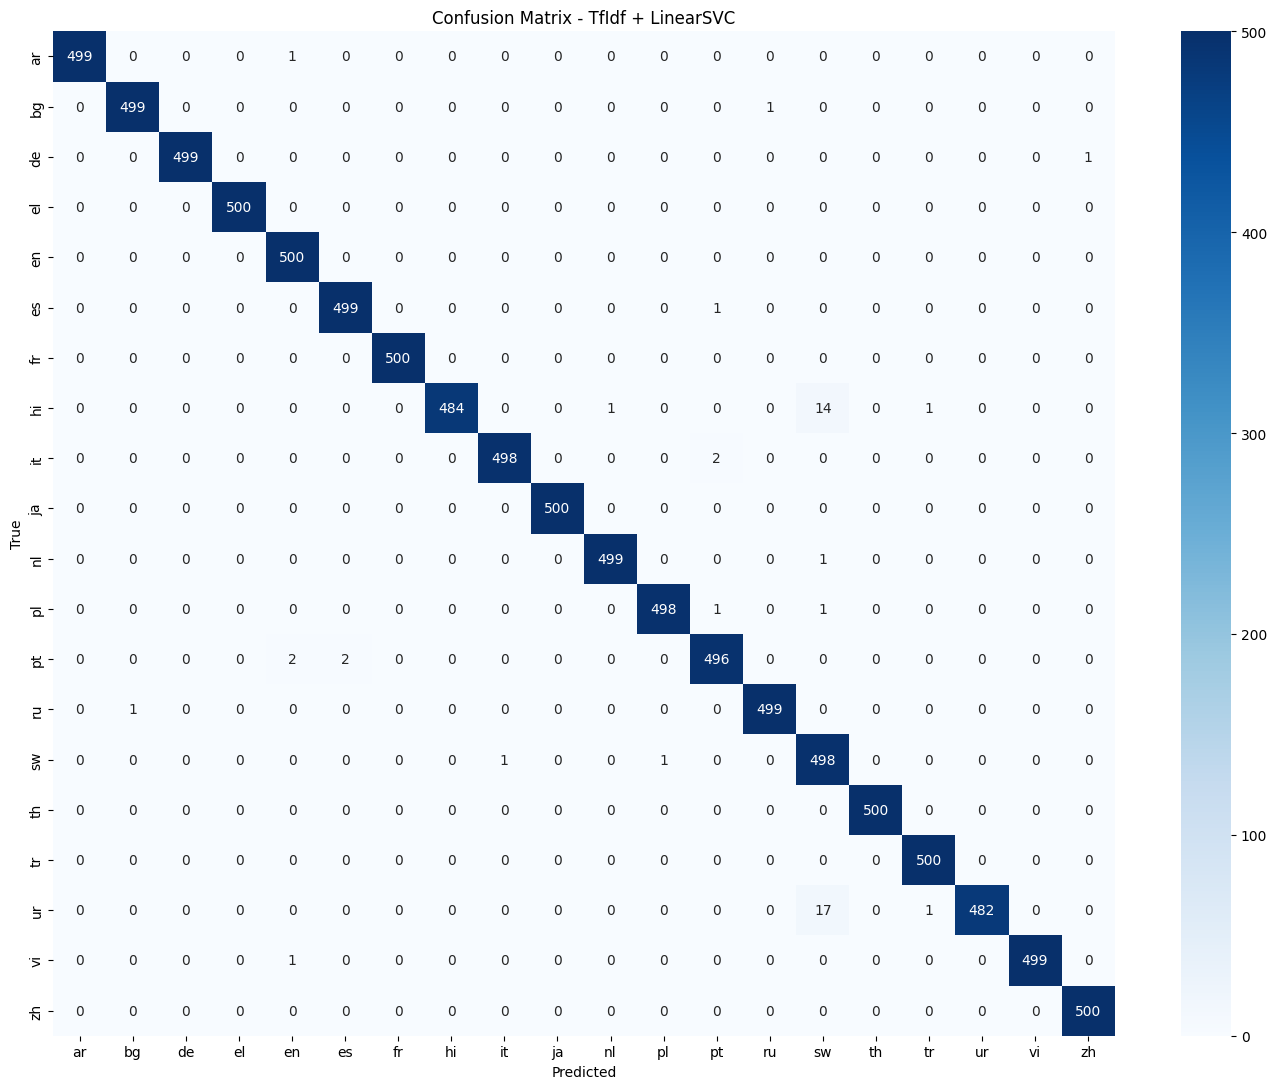

In [12]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, test_preds, labels=labels)
plt.figure(figsize=(14, 11))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title(f"Confusion Matrix - {best_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## 9. Short-Text Sanity Checks
The critical test: does the model correctly classify very short inputs?

In [13]:
short_tests = [
    ("hi", "en"),
    ("hello", "en"),
    ("hey", "en"),
    ("ok", "en"),
    ("thanks", "en"),
    ("how are you", "en"),
    ("i am mohammed", "en"),
    ("good morning", "en"),
    ("i feel sad", "en"),
    ("help me", "en"),
    ("hola", "es"),
    ("buenos dias", "es"),
    ("gracias", "es"),
    ("bonjour", "fr"),
    ("merci", "fr"),
    ("salut", "fr"),
    ("ciao", "it"),
    ("مرحبا", "ar"),
    ("عامل ايه", "ar"),
    ("شكرا", "ar"),
    ("привет", "ru"),
    ("спасибо", "ru"),
    ("你好", "zh"),
    ("谢谢", "zh"),
    ("こんにちは", "ja"),
    ("안녕하세요", "ko"),
    ("danke", "de"),
    ("guten morgen", "de"),
    ("obrigado", "pt"),
    ("नमस्ते", "hi"),
]

print("=" * 60)
print(f"Short-Text Sanity Check - All {len(pipelines)} Pipelines")
print("=" * 60)

for name, pipe in pipelines.items():
    correct = 0
    print(f"\n[{name}]")
    for text, expected in short_tests:
        pred = pipe.predict([text])[0]
        status = "PASS" if pred == expected else "FAIL"
        if pred == expected:
            correct += 1
        print(f'  {status} "{text}" -> {pred} (expected {expected})')
    print(f"  Score: {correct}/{len(short_tests)} ({100*correct/len(short_tests):.1f}%)")

Short-Text Sanity Check - All 6 Pipelines

[Count + LogReg]
  PASS "hi" -> en (expected en)
  PASS "hello" -> en (expected en)
  PASS "hey" -> en (expected en)
  PASS "ok" -> en (expected en)
  PASS "thanks" -> en (expected en)
  PASS "how are you" -> en (expected en)
  PASS "i am mohammed" -> en (expected en)
  PASS "good morning" -> en (expected en)
  PASS "i feel sad" -> en (expected en)
  PASS "help me" -> en (expected en)
  PASS "hola" -> es (expected es)
  PASS "buenos dias" -> es (expected es)
  PASS "gracias" -> es (expected es)
  PASS "bonjour" -> fr (expected fr)
  PASS "merci" -> fr (expected fr)
  PASS "salut" -> fr (expected fr)
  PASS "ciao" -> it (expected it)
  PASS "مرحبا" -> ar (expected ar)
  PASS "عامل ايه" -> ar (expected ar)
  PASS "شكرا" -> ar (expected ar)
  PASS "привет" -> ru (expected ru)
  PASS "спасибо" -> ru (expected ru)
  PASS "你好" -> zh (expected zh)
  PASS "谢谢" -> zh (expected zh)
  PASS "こんにちは" -> ja (expected ja)
  FAIL "안녕하세요" -> zh (expected ko)
  

## 10. Save Best Model

In [14]:
os.makedirs("models", exist_ok=True)
model_path = "models/language_classification_pipeline.joblib"
joblib.dump(best_pipe, model_path)
print(f"Best model ({best_name}) saved to: {model_path}")

Best model (TfIdf + LinearSVC) saved to: models/language_classification_pipeline.joblib
